<a href="https://colab.research.google.com/github/Horeisan/Neural-Network-Performance-Analysis/blob/main/EnergyEfficiency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Preparation

###Importing Dataset

In [1]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
energy_efficiency = fetch_ucirepo(id=242)

# data (as pandas dataframes)
X = energy_efficiency.data.features
y = energy_efficiency.data.targets

# metadata
print(energy_efficiency.metadata)

# variable information
print(energy_efficiency.variables)

{'uci_id': 242, 'name': 'Energy Efficiency', 'repository_url': 'https://archive.ics.uci.edu/dataset/242/energy+efficiency', 'data_url': 'https://archive.ics.uci.edu/static/public/242/data.csv', 'abstract': 'This study looked into assessing the heating load and cooling load requirements of buildings (that is, energy efficiency) as a function of building parameters.', 'area': 'Computer Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 768, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y1', 'Y2'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C51307', 'creators': ['Athanasios Tsanas', 'Angeliki Xifara'], 'intro_paper': {'ID': 379, 'type': 'NATIVE', 'title': 'Accurate quantitative estimation of energy performance of residential buildings using statistical machine 

###Analysing dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

display(X.isna().sum())
display(y.isna().sum())
X.describe()

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0


,0
Y1,0
Y2,0


,X1,X2,X3,X4,X5,X6,X7,X8
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000


The dataset has no empty values as you can see also in the dataset documentation

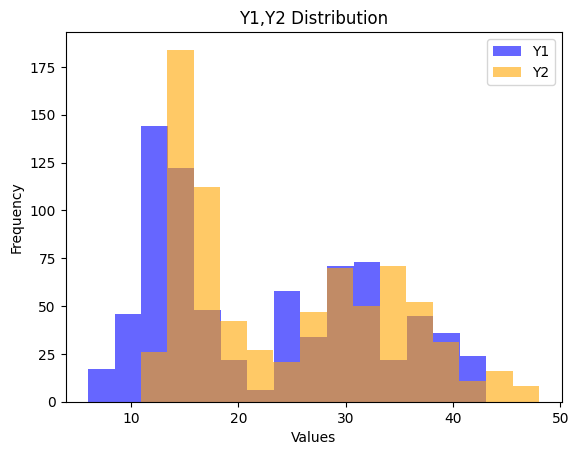

In [3]:

plt.hist(y['Y1'], bins=15, alpha=0.6, color='blue', label='Y1')
plt.hist(y['Y2'], bins=15, alpha=0.6, color='orange', label='Y2')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Y1,Y2 Distribution')


plt.legend()
plt.show()

Most buildings have lower heating and cooling demands, while fewer require high energy loads.
This indicates that the dataset covers a balanced variety of building configurations, making it suitable for regression analysis of energy efficiency

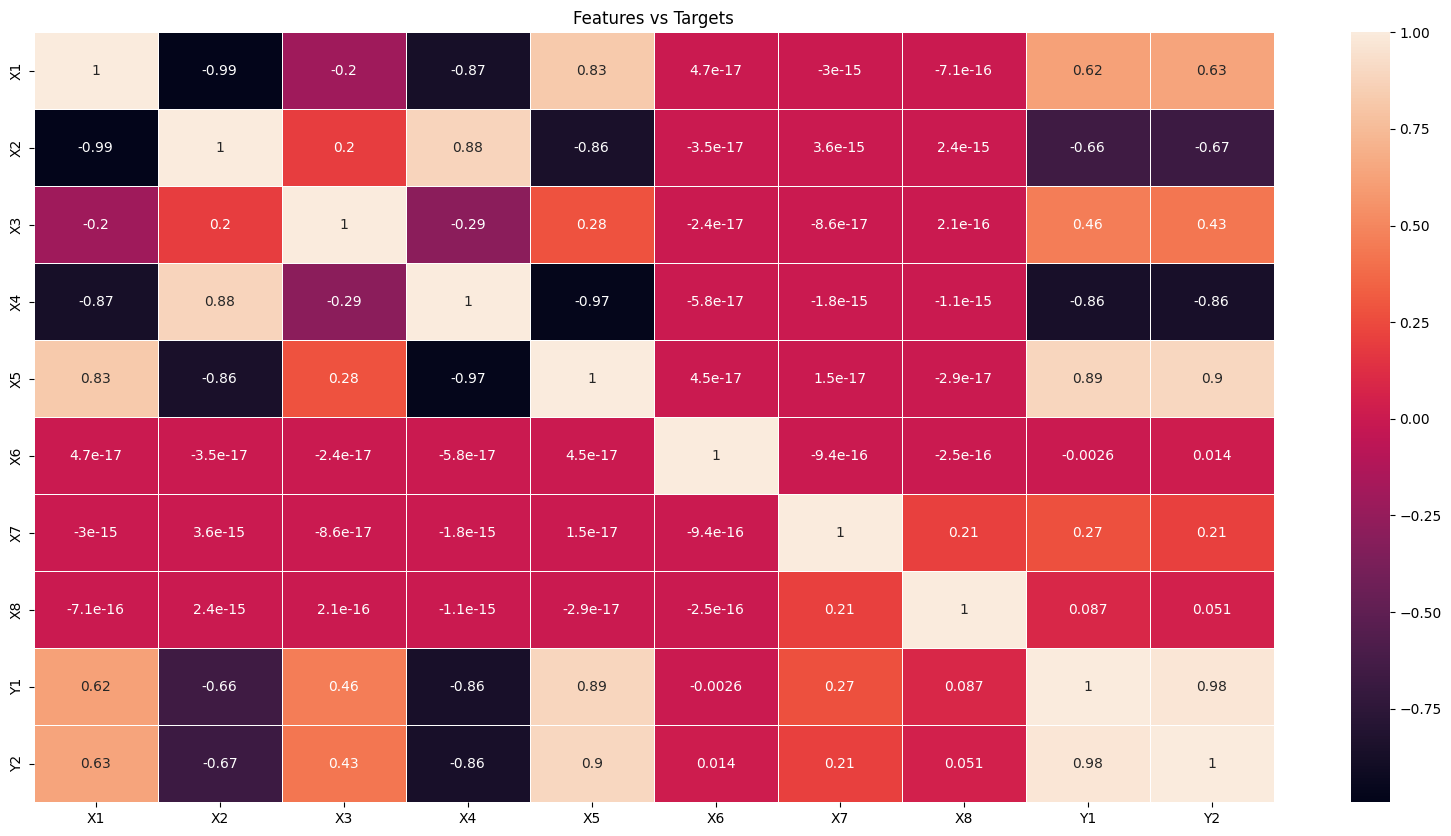

In [4]:
import seaborn as sns


X_df = pd.DataFrame(X, columns=energy_efficiency.data.features.columns)
data = pd.concat([X_df, y], axis=1)

plt.figure(figsize=(20, 10))
sns.heatmap(data.corr(), annot=True, linewidths=.5)
plt.title("Features vs Targets")
plt.show()


Overall Height **X5** shows the strongest positive correlation with both Y1 and Y2 **0.9**, while Relative Compactness **X1** and Surface Area **X2** are strongly negatively correlated with the targets **-0.86**

###Dataset splitting

In [5]:
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd


X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_cv, y_train, y_cv = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

X_df = pd.DataFrame(X_temp, columns=X.columns)
X_np = X_df.values.astype(np.float32)
y_np = y_temp.values.astype(np.float32)


display(X_np.shape)



(614, 8)

#Creating a single MLP

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class BaselineMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(BaselineMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
    def forward(self, x):
        return self.net(x)


###Splitting into k folds with the learning rate of `0.001`

In [24]:
num_epochs = 50
batch_size = 32
fold_results = []
train_losses_last = []
val_losses_last = []


for fold, (train_idx, val_idx) in enumerate(kf.split(X_np)):
    X_train_fold = X_np[train_idx]
    y_train_fold = y_np[train_idx]
    X_val_fold = X_np[val_idx]
    y_val_fold = y_np[val_idx]

    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold = scaler.transform(X_val_fold)

    X_train_fold = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_fold = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)


    train_loader = DataLoader(TensorDataset(X_train_fold, y_train_fold),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_fold, y_val_fold),
                            batch_size=batch_size, shuffle=False)

    out_dim = y_train_fold.shape[1]
    model = BaselineMLP(input_dim=X_train_fold.shape[1], output_dim=out_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses_fold = []
    val_losses_fold = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
        avg_loss = total_loss / len(train_loader.dataset)
        train_losses_fold.append(avg_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses_fold.append(avg_val_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Fold {fold+1} | Epoch {epoch}/{num_epochs} | "
                  f"Train Loss: {avg_loss:.1f} | Val Loss: {avg_val_loss:.1f}")

    fold_results.append(avg_val_loss)

    train_losses_last.append(train_losses_fold)
    val_losses_last.append(val_losses_fold)

    print("\n")



mean_loss = np.mean(fold_results)

mean_loss_00001 = mean_loss

print(f"\nMean CV Loss: {mean_loss.round(2)}")

Fold 1 | Epoch 0/50 | Train Loss: 635.1 | Val Loss: 637.2
Fold 1 | Epoch 4/50 | Train Loss: 96.9 | Val Loss: 35.9
Fold 1 | Epoch 9/50 | Train Loss: 47.2 | Val Loss: 24.0
Fold 1 | Epoch 14/50 | Train Loss: 39.8 | Val Loss: 17.2
Fold 1 | Epoch 19/50 | Train Loss: 31.4 | Val Loss: 14.7
Fold 1 | Epoch 24/50 | Train Loss: 33.7 | Val Loss: 12.9
Fold 1 | Epoch 29/50 | Train Loss: 30.1 | Val Loss: 10.4
Fold 1 | Epoch 34/50 | Train Loss: 29.4 | Val Loss: 10.7
Fold 1 | Epoch 39/50 | Train Loss: 29.6 | Val Loss: 10.4
Fold 1 | Epoch 44/50 | Train Loss: 24.9 | Val Loss: 9.4
Fold 1 | Epoch 49/50 | Train Loss: 29.0 | Val Loss: 10.1


Fold 2 | Epoch 0/50 | Train Loss: 635.4 | Val Loss: 650.0
Fold 2 | Epoch 4/50 | Train Loss: 101.5 | Val Loss: 53.7
Fold 2 | Epoch 9/50 | Train Loss: 51.2 | Val Loss: 31.5
Fold 2 | Epoch 14/50 | Train Loss: 45.2 | Val Loss: 24.5
Fold 2 | Epoch 19/50 | Train Loss: 35.9 | Val Loss: 20.1
Fold 2 | Epoch 24/50 | Train Loss: 31.9 | Val Loss: 17.5
Fold 2 | Epoch 29/50 | Train Lo

###Plotting the curve for each fold

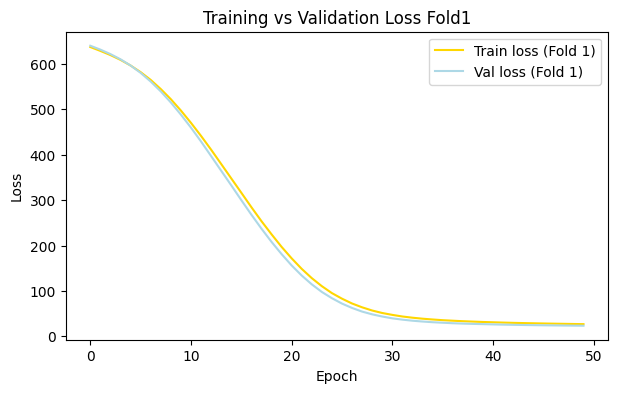

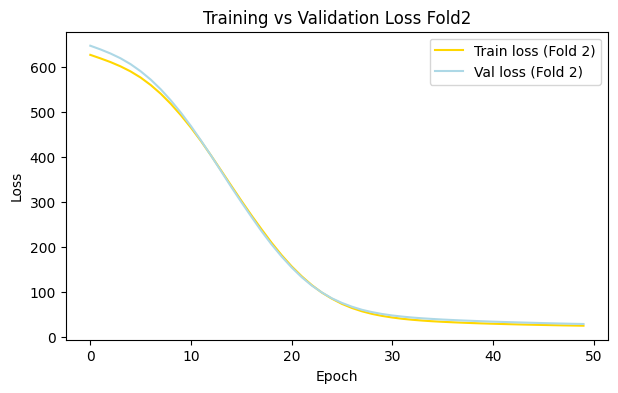

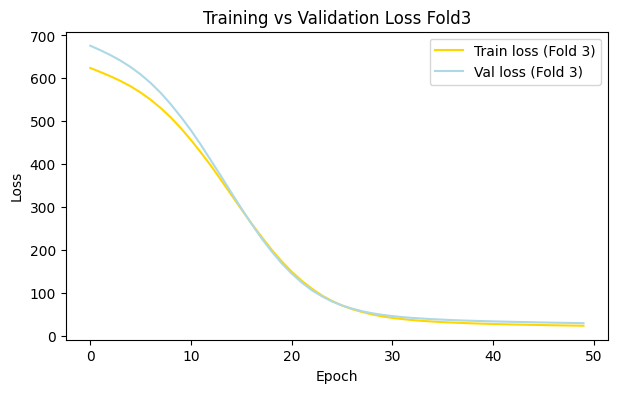

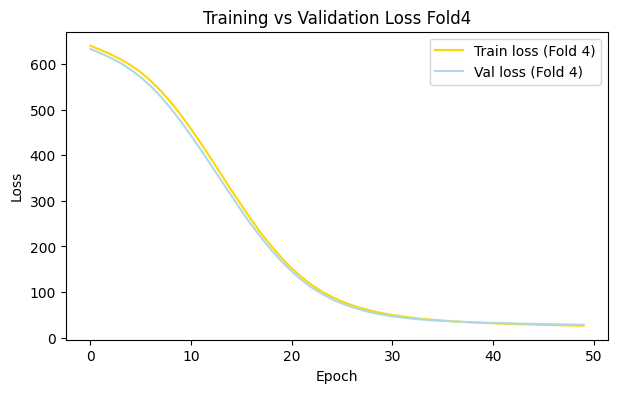

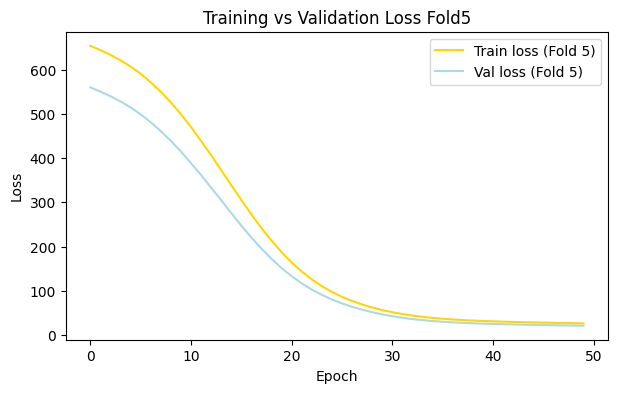

In [8]:
for i in range(len(train_losses_last)):


    plt.figure(figsize=(7,4))
    plt.plot(train_losses_last[i], label=f'Train loss (Fold {i+1})', color='gold')
    plt.plot(val_losses_last[i], label=f'Val loss (Fold {i+1})', color='lightblue')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training vs Validation Loss Fold{i+1}')
    plt.legend()
    plt.show()


In this experiment, we trained a **Baseline MLP** model using **K-Fold Cross-Validation**

**Loss Function:** `MSE`

**Optimizer:** Adam `learning = 0.001`  


**Training Parameters**

   Number of epochs: 50

   Batch size: 32  

   Evaluation metric: Mean validation loss per fold

At the end, the code reports the **mean cross-validation loss** and **standard deviation** across all folds.


#Changed learning rate to `0.01`



In [9]:
num_epochs = 50
batch_size = 32
fold_results = []
train_losses_last = []
val_losses_last = []


for fold, (train_idx, val_idx) in enumerate(kf.split(X_np)):
    X_train_fold = X_np[train_idx]
    y_train_fold = y_np[train_idx]
    X_val_fold = X_np[val_idx]
    y_val_fold = y_np[val_idx]

    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold = scaler.transform(X_val_fold)

    X_train_fold = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_fold = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)


    train_loader = DataLoader(TensorDataset(X_train_fold, y_train_fold),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_fold, y_val_fold),
                            batch_size=batch_size, shuffle=False)

    out_dim = y_train_fold.shape[1]
    model = BaselineMLP(input_dim=X_train_fold.shape[1], output_dim=out_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    train_losses_fold = []
    val_losses_fold = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
        avg_loss = total_loss / len(train_loader.dataset)
        train_losses_fold.append(avg_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses_fold.append(avg_val_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Fold {fold+1} | Epoch {epoch}/{num_epochs} | "
                  f"Train Loss: {avg_loss:.1f} | Val Loss: {avg_val_loss:.1f}")

    fold_results.append(avg_val_loss)

    train_losses_last.append(train_losses_fold)
    val_losses_last.append(val_losses_fold)

    print("\n")



mean_loss = np.mean(fold_results)

mean_loss_001 = mean_loss

print(f"\nMean CV Loss: {mean_loss.round(2)}")

Fold 1 | Epoch 0/50 | Train Loss: 587.0 | Val Loss: 522.0
Fold 1 | Epoch 4/50 | Train Loss: 34.7 | Val Loss: 24.2
Fold 1 | Epoch 9/50 | Train Loss: 17.9 | Val Loss: 15.8
Fold 1 | Epoch 14/50 | Train Loss: 11.7 | Val Loss: 10.9
Fold 1 | Epoch 19/50 | Train Loss: 9.8 | Val Loss: 9.4
Fold 1 | Epoch 24/50 | Train Loss: 9.5 | Val Loss: 9.0
Fold 1 | Epoch 29/50 | Train Loss: 9.3 | Val Loss: 9.3
Fold 1 | Epoch 34/50 | Train Loss: 8.8 | Val Loss: 9.0
Fold 1 | Epoch 39/50 | Train Loss: 8.8 | Val Loss: 8.9
Fold 1 | Epoch 44/50 | Train Loss: 8.5 | Val Loss: 8.8
Fold 1 | Epoch 49/50 | Train Loss: 8.4 | Val Loss: 8.6


Fold 2 | Epoch 0/50 | Train Loss: 596.7 | Val Loss: 555.8
Fold 2 | Epoch 4/50 | Train Loss: 31.6 | Val Loss: 29.6
Fold 2 | Epoch 9/50 | Train Loss: 17.5 | Val Loss: 19.4
Fold 2 | Epoch 14/50 | Train Loss: 12.0 | Val Loss: 13.4
Fold 2 | Epoch 19/50 | Train Loss: 9.4 | Val Loss: 11.0
Fold 2 | Epoch 24/50 | Train Loss: 8.9 | Val Loss: 10.1
Fold 2 | Epoch 29/50 | Train Loss: 8.6 | Val Lo

###Plotting the curve for each fold

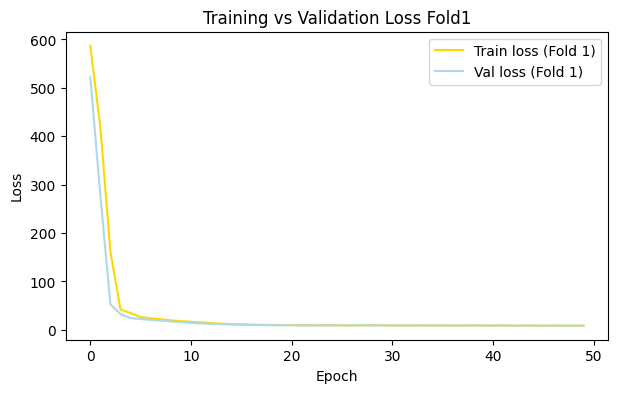

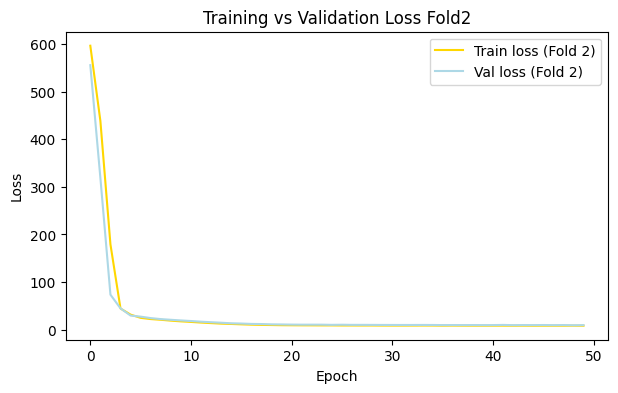

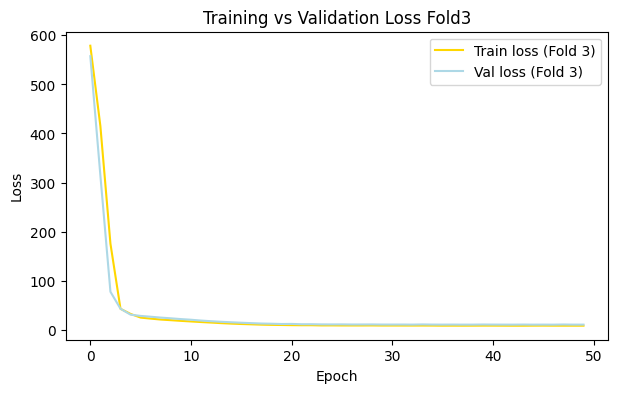

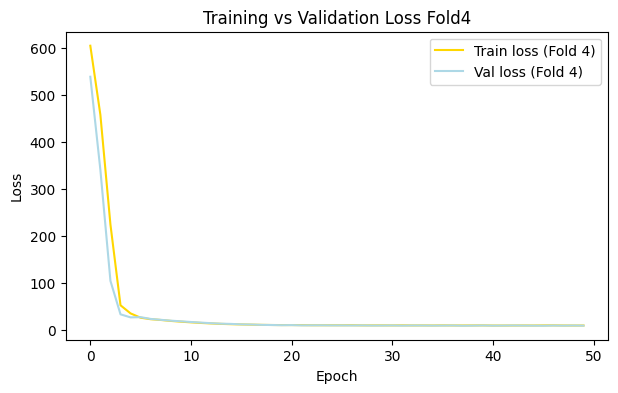

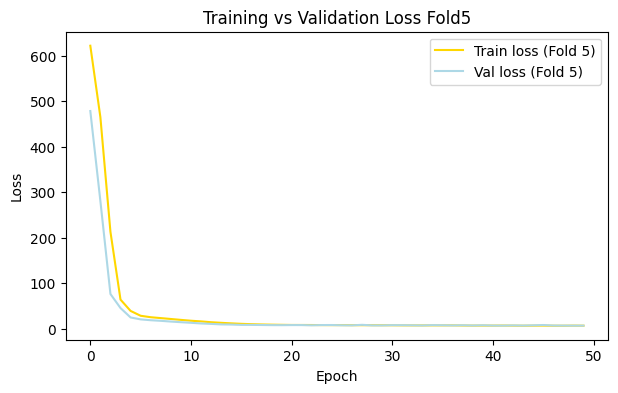

In [10]:
for i in range(len(train_losses_last)):


    plt.figure(figsize=(7,4))
    plt.plot(train_losses_last[i], label=f'Train loss (Fold {i+1})', color='gold')
    plt.plot(val_losses_last[i], label=f'Val loss (Fold {i+1})', color='lightblue')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training vs Validation Loss Fold{i+1}')
    plt.legend()
    plt.show()

Each plot represents one K-Fold training run, showing how the model’s training and validation losses evolve over epochs.
The gold and blue curves decrease steadily, indicating that the model is learning effectively and generalizing well without strong overfitting.
Overall, the consistent downward trend across folds confirms stable training performance and reliable optimization.

#Using `SGD` optimiser instead of `Adam`

In [11]:
num_epochs = 50
batch_size = 32
fold_results = []
train_losses_last = []
val_losses_last = []


for fold, (train_idx, val_idx) in enumerate(kf.split(X_np)):
    X_train_fold = X_np[train_idx]
    y_train_fold = y_np[train_idx]
    X_val_fold = X_np[val_idx]
    y_val_fold = y_np[val_idx]

    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold = scaler.transform(X_val_fold)

    X_train_fold = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_fold = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_train_fold, y_train_fold),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_fold, y_val_fold),
                            batch_size=batch_size, shuffle=False)

    out_dim = y_train_fold.shape[1]
    model = BaselineMLP(input_dim=X_train_fold.shape[1], output_dim=out_dim).to(device)
    criterion = nn.MSELoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

    train_losses_fold = []
    val_losses_fold = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
        avg_loss = total_loss / len(train_loader.dataset)
        train_losses_fold.append(avg_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses_fold.append(avg_val_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Fold {fold+1} | Epoch {epoch}/{num_epochs} | "
                  f"Train Loss: {avg_loss:.1f} | Val Loss: {avg_val_loss:.1f}")

    fold_results.append(avg_val_loss)

    train_losses_last.append(train_losses_fold)
    val_losses_last.append(val_losses_fold)

    print("\n")


mean_loss = np.mean(fold_results)

mean_loss_sgd = mean_loss

print(f"\nMean CV Loss: {mean_loss.round(2)}")


Fold 1 | Epoch 0/50 | Train Loss: 617.7 | Val Loss: 599.5
Fold 1 | Epoch 4/50 | Train Loss: 123.6 | Val Loss: 76.8
Fold 1 | Epoch 9/50 | Train Loss: 20.9 | Val Loss: 17.7
Fold 1 | Epoch 14/50 | Train Loss: 16.1 | Val Loss: 13.8
Fold 1 | Epoch 19/50 | Train Loss: 13.6 | Val Loss: 11.9
Fold 1 | Epoch 24/50 | Train Loss: 12.3 | Val Loss: 10.7
Fold 1 | Epoch 29/50 | Train Loss: 11.4 | Val Loss: 10.0
Fold 1 | Epoch 34/50 | Train Loss: 10.7 | Val Loss: 9.6
Fold 1 | Epoch 39/50 | Train Loss: 10.2 | Val Loss: 9.3
Fold 1 | Epoch 44/50 | Train Loss: 9.9 | Val Loss: 9.0
Fold 1 | Epoch 49/50 | Train Loss: 9.7 | Val Loss: 8.9


Fold 2 | Epoch 0/50 | Train Loss: 604.8 | Val Loss: 587.0
Fold 2 | Epoch 4/50 | Train Loss: 78.2 | Val Loss: 68.8
Fold 2 | Epoch 9/50 | Train Loss: 21.4 | Val Loss: 23.9
Fold 2 | Epoch 14/50 | Train Loss: 16.6 | Val Loss: 18.5
Fold 2 | Epoch 19/50 | Train Loss: 14.0 | Val Loss: 15.7
Fold 2 | Epoch 24/50 | Train Loss: 12.3 | Val Loss: 13.8
Fold 2 | Epoch 29/50 | Train Loss: 1

###Plotting the curve for each fold

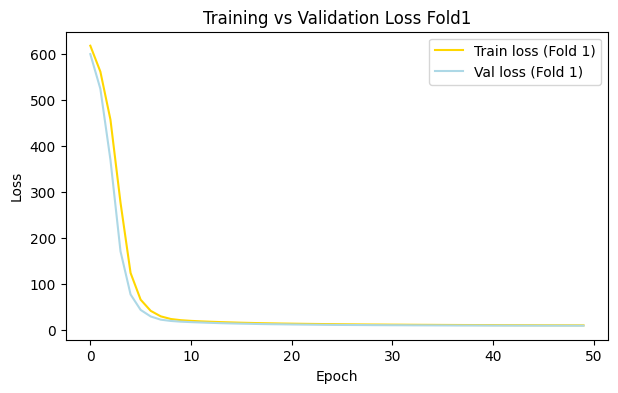

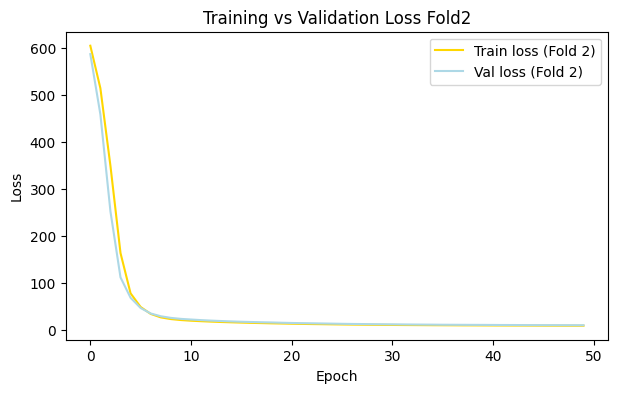

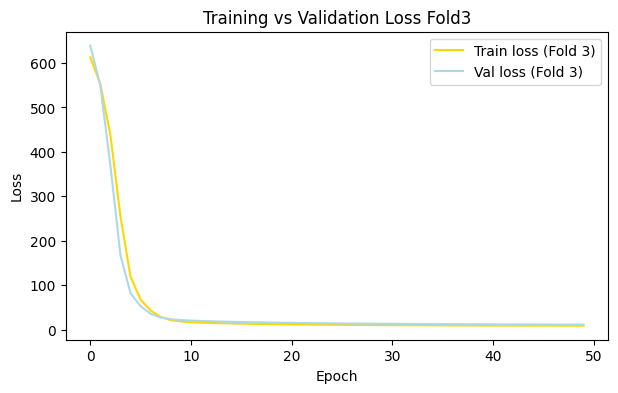

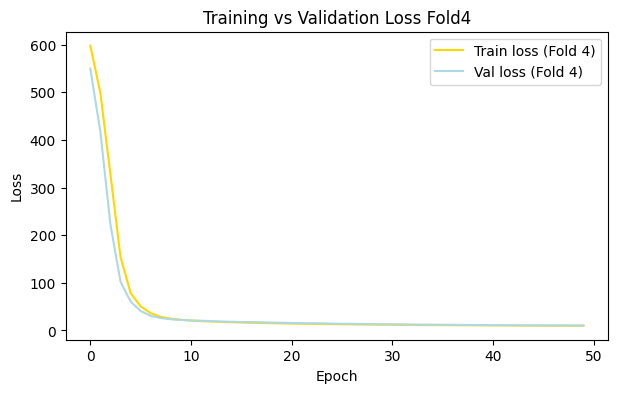

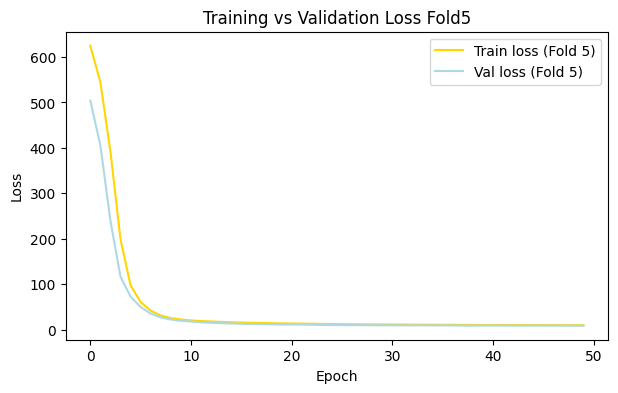

In [12]:
for i in range(len(train_losses_last)):


    plt.figure(figsize=(7,4))
    plt.plot(train_losses_last[i], label=f'Train loss (Fold {i+1})', color='gold')
    plt.plot(val_losses_last[i], label=f'Val loss (Fold {i+1})', color='lightblue')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training vs Validation Loss Fold{i+1}')
    plt.legend()
    plt.show()

The MSE loss remains the same, but with SGD, the learning rate usually needs to be smaller than with Adam to achieve stable convergence.

#Creating Mlp with 4 hidden layers

In [13]:
class MLP4(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP4, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [14]:
num_epochs = 50
batch_size = 32
fold_results = []
train_losses_last = []
val_losses_last = []


for fold, (train_idx, val_idx) in enumerate(kf.split(X_np)):
    X_train_fold = X_np[train_idx]
    y_train_fold = y_np[train_idx]
    X_val_fold = X_np[val_idx]
    y_val_fold = y_np[val_idx]

    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold = scaler.transform(X_val_fold)

    X_train_fold = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_fold = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_train_fold, y_train_fold),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_fold, y_val_fold),
                            batch_size=batch_size, shuffle=False)

    out_dim = y_train_fold.shape[1]

    model = MLP4(input_dim=X_train_fold.shape[1], output_dim=out_dim).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses_fold = []
    val_losses_fold = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
        avg_loss = total_loss / len(train_loader.dataset)
        train_losses_fold.append(avg_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses_fold.append(avg_val_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Fold {fold+1} | Epoch {epoch}/{num_epochs} | "
                  f"Train Loss: {avg_loss:.1f} | Val Loss: {avg_val_loss:.1f}")

    fold_results.append(avg_val_loss)
    train_losses_last.append(train_losses_fold)
    val_losses_last.append(val_losses_fold)
    print("\n")


mean_loss = np.mean(fold_results)

mean_loss_4layers = mean_loss

print(f"\nMean CV Loss: {mean_loss.round(2)}")


Fold 1 | Epoch 0/50 | Train Loss: 628.0 | Val Loss: 633.0
Fold 1 | Epoch 4/50 | Train Loss: 114.5 | Val Loss: 60.4
Fold 1 | Epoch 9/50 | Train Loss: 24.7 | Val Loss: 21.4
Fold 1 | Epoch 14/50 | Train Loss: 18.8 | Val Loss: 17.0
Fold 1 | Epoch 19/50 | Train Loss: 14.9 | Val Loss: 13.1
Fold 1 | Epoch 24/50 | Train Loss: 11.4 | Val Loss: 10.5
Fold 1 | Epoch 29/50 | Train Loss: 9.5 | Val Loss: 9.1
Fold 1 | Epoch 34/50 | Train Loss: 8.2 | Val Loss: 7.8
Fold 1 | Epoch 39/50 | Train Loss: 7.5 | Val Loss: 7.2
Fold 1 | Epoch 44/50 | Train Loss: 6.8 | Val Loss: 6.8
Fold 1 | Epoch 49/50 | Train Loss: 6.4 | Val Loss: 6.5


Fold 2 | Epoch 0/50 | Train Loss: 628.0 | Val Loss: 643.4
Fold 2 | Epoch 4/50 | Train Loss: 58.2 | Val Loss: 48.2
Fold 2 | Epoch 9/50 | Train Loss: 22.3 | Val Loss: 26.5
Fold 2 | Epoch 14/50 | Train Loss: 16.6 | Val Loss: 19.7
Fold 2 | Epoch 19/50 | Train Loss: 13.1 | Val Loss: 15.6
Fold 2 | Epoch 24/50 | Train Loss: 11.2 | Val Loss: 12.9
Fold 2 | Epoch 29/50 | Train Loss: 10.0 

###Plotting the curve for each fold

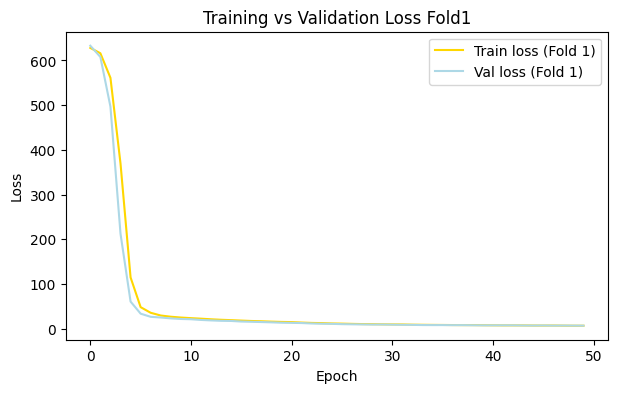

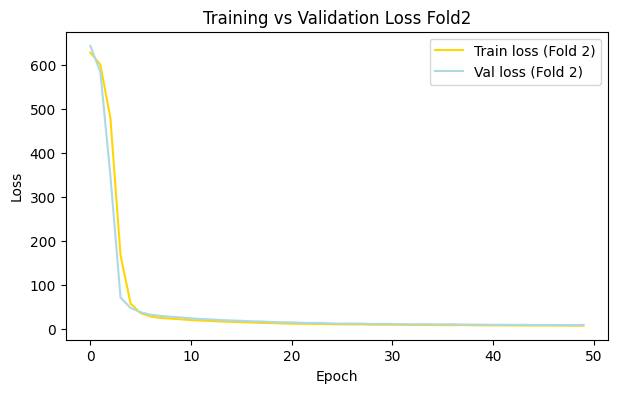

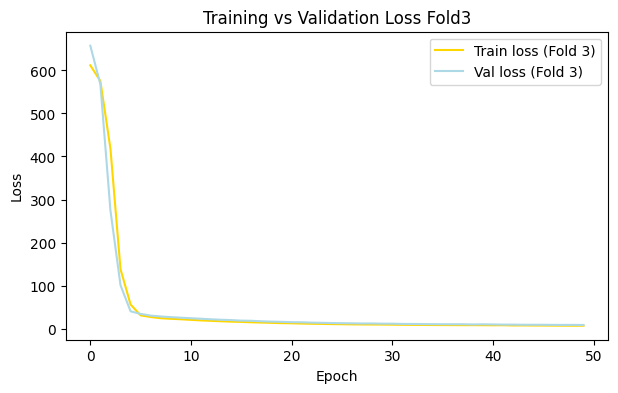

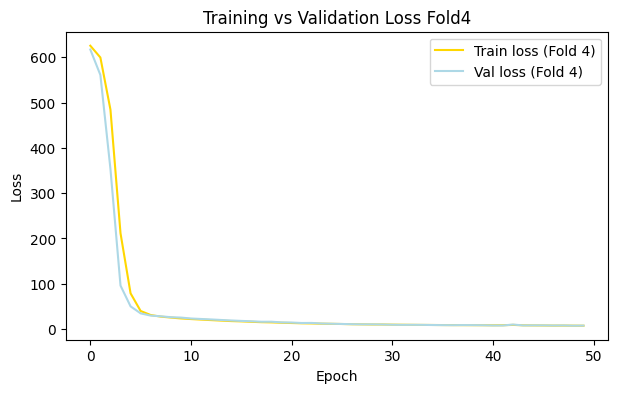

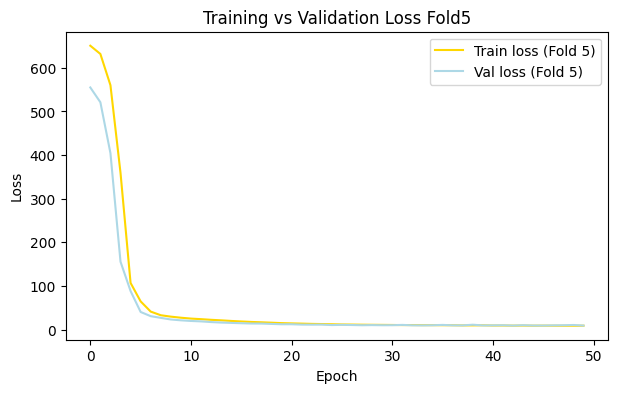

In [15]:
for i in range(len(train_losses_last)):


    plt.figure(figsize=(7,4))
    plt.plot(train_losses_last[i], label=f'Train loss (Fold {i+1})', color='gold')
    plt.plot(val_losses_last[i], label=f'Val loss (Fold {i+1})', color='lightblue')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training vs Validation Loss Fold{i+1}')
    plt.legend()
    plt.show()

In this experiment, we trained MLP with 4 hidden layersmodel using K-Fold Cross-Validation

Loss Function: `MSE`

Optimizer: `Adam learning = 0.01`

Training Parameters

Number of epochs: 50

Batch size: 32

Evaluation metric: Mean validation loss per fold

At the end, the code reports the mean cross-validation loss and standard deviation across all folds.

Although this MLP has 4 hidden layers, each using the same activation function **relu**, conceptually they all perform the same type of operation — a linear transformation followed by a ReLU. The difference lies only in how many times this process is repeated, not in the function itself.

#Using Regularisation On The Single Mlp

In [16]:
num_epochs = 50
batch_size = 32
fold_results = []
train_losses_last = []
val_losses_last = []


for fold, (train_idx, val_idx) in enumerate(kf.split(X_np)):
    X_train_fold = X_np[train_idx]
    y_train_fold = y_np[train_idx]
    X_val_fold = X_np[val_idx]
    y_val_fold = y_np[val_idx]

    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold = scaler.transform(X_val_fold)

    X_train_fold = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_fold = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)


    train_loader = DataLoader(TensorDataset(X_train_fold, y_train_fold),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_fold, y_val_fold),
                            batch_size=batch_size, shuffle=False)

    out_dim = y_train_fold.shape[1]
    model = BaselineMLP(input_dim=X_train_fold.shape[1], output_dim=out_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.0001)

    train_losses_fold = []
    val_losses_fold = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
        avg_loss = total_loss / len(train_loader.dataset)
        train_losses_fold.append(avg_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses_fold.append(avg_val_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Fold {fold+1} | Epoch {epoch}/{num_epochs} | "
                  f"Train Loss: {avg_loss:.1f} | Val Loss: {avg_val_loss:.1f}")

    fold_results.append(avg_val_loss)

    train_losses_last.append(train_losses_fold)
    val_losses_last.append(val_losses_fold)

    print("\n")



mean_loss = np.mean(fold_results)

mean_loss_regularisation = mean_loss

print(f"\nMean CV Loss: {mean_loss.round(2)}")

Fold 1 | Epoch 0/50 | Train Loss: 620.1 | Val Loss: 574.0
Fold 1 | Epoch 4/50 | Train Loss: 41.6 | Val Loss: 27.7
Fold 1 | Epoch 9/50 | Train Loss: 19.7 | Val Loss: 16.8
Fold 1 | Epoch 14/50 | Train Loss: 12.2 | Val Loss: 10.9
Fold 1 | Epoch 19/50 | Train Loss: 9.5 | Val Loss: 9.2
Fold 1 | Epoch 24/50 | Train Loss: 8.9 | Val Loss: 9.1
Fold 1 | Epoch 29/50 | Train Loss: 8.8 | Val Loss: 9.0
Fold 1 | Epoch 34/50 | Train Loss: 8.7 | Val Loss: 9.0
Fold 1 | Epoch 39/50 | Train Loss: 8.8 | Val Loss: 9.0
Fold 1 | Epoch 44/50 | Train Loss: 8.9 | Val Loss: 9.3
Fold 1 | Epoch 49/50 | Train Loss: 8.5 | Val Loss: 8.8


Fold 2 | Epoch 0/50 | Train Loss: 601.4 | Val Loss: 555.0
Fold 2 | Epoch 4/50 | Train Loss: 37.1 | Val Loss: 37.9
Fold 2 | Epoch 9/50 | Train Loss: 19.1 | Val Loss: 21.9
Fold 2 | Epoch 14/50 | Train Loss: 12.4 | Val Loss: 14.4
Fold 2 | Epoch 19/50 | Train Loss: 9.5 | Val Loss: 10.8
Fold 2 | Epoch 24/50 | Train Loss: 8.9 | Val Loss: 10.1
Fold 2 | Epoch 29/50 | Train Loss: 8.7 | Val Lo

###Plotting the curve for each fold

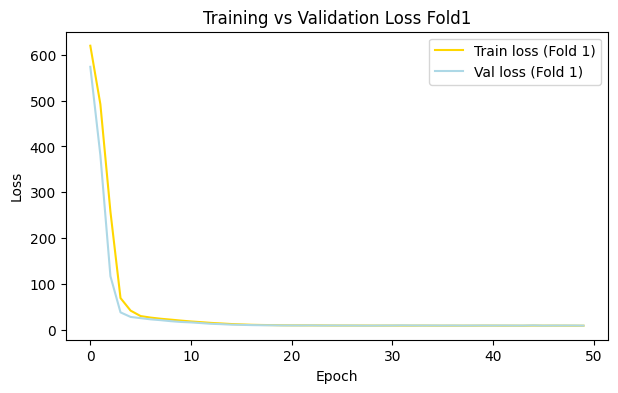

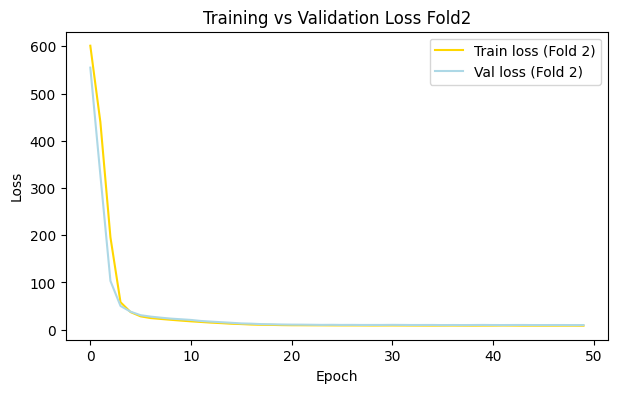

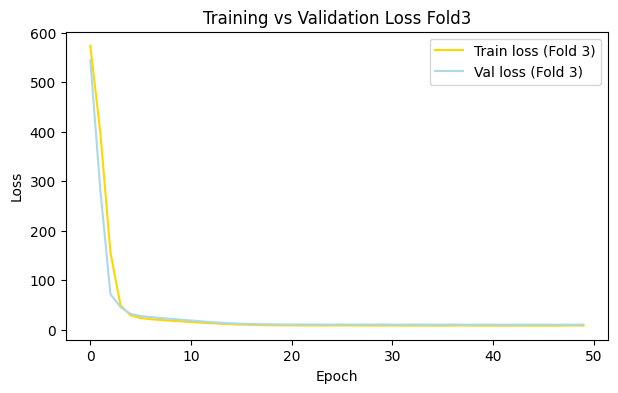

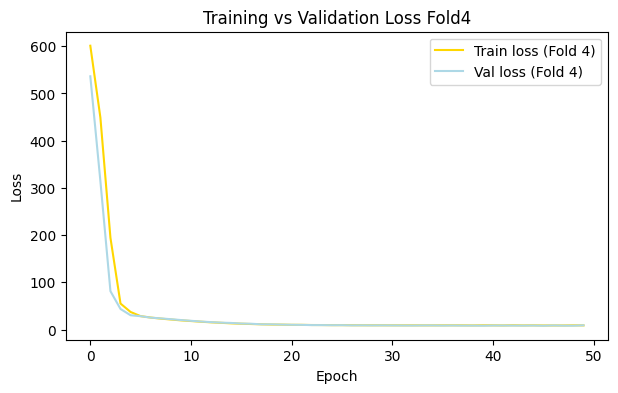

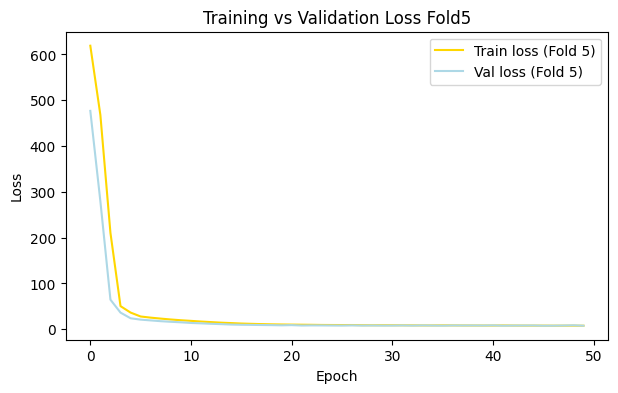

In [17]:
for i in range(len(train_losses_last)):


    plt.figure(figsize=(7,4))
    plt.plot(train_losses_last[i], label=f'Train loss (Fold {i+1})', color='gold')
    plt.plot(val_losses_last[i], label=f'Val loss (Fold {i+1})', color='lightblue')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training vs Validation Loss Fold{i+1}')
    plt.legend()
    plt.show()

The addition of L2 regularization (weight decay = 0.0001) helped improve the models generalization and stability across folds.

Compared to the previous configuration, the mean cross-validation loss decreased slightly, showing that the penalty on large weights reduced overfitting and made the training more balanced between the training and validation sets.

#Using a dropout rate of 0.1

In [18]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, output_dim, p=0.1):
        super(BaselineMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(16, output_dim)
        )

    def forward(self, x):
        return self.net(x)


In [19]:
num_epochs = 50
batch_size = 32
fold_results = []
train_losses_last = []
val_losses_last = []


for fold, (train_idx, val_idx) in enumerate(kf.split(X_np)):
    X_train_fold = X_np[train_idx]
    y_train_fold = y_np[train_idx]
    X_val_fold = X_np[val_idx]
    y_val_fold = y_np[val_idx]

    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold = scaler.transform(X_val_fold)

    X_train_fold = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_fold = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_fold = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_fold = torch.tensor(y_val_fold, dtype=torch.float32)


    train_loader = DataLoader(TensorDataset(X_train_fold, y_train_fold),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_fold, y_val_fold),
                            batch_size=batch_size, shuffle=False)

    out_dim = y_train_fold.shape[1]
    model = BaselineMLP(input_dim=X_train_fold.shape[1], output_dim=out_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.0001)

    train_losses_fold = []
    val_losses_fold = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
        avg_loss = total_loss / len(train_loader.dataset)
        train_losses_fold.append(avg_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses_fold.append(avg_val_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Fold {fold+1} | Epoch {epoch}/{num_epochs} | "
                  f"Train Loss: {avg_loss:.1f} | Val Loss: {avg_val_loss:.1f}")

    fold_results.append(avg_val_loss)

    train_losses_last.append(train_losses_fold)
    val_losses_last.append(val_losses_fold)

    print("\n")



mean_loss = np.mean(fold_results)

mean_loss_dropout = mean_loss

print(f"\nMean CV Loss: {mean_loss.round(2)}")

Fold 1 | Epoch 0/50 | Train Loss: 393.2 | Val Loss: 36.9
Fold 1 | Epoch 4/50 | Train Loss: 33.8 | Val Loss: 14.8
Fold 1 | Epoch 9/50 | Train Loss: 29.7 | Val Loss: 16.9
Fold 1 | Epoch 14/50 | Train Loss: 33.2 | Val Loss: 13.1
Fold 1 | Epoch 19/50 | Train Loss: 24.5 | Val Loss: 9.4
Fold 1 | Epoch 24/50 | Train Loss: 23.7 | Val Loss: 20.9
Fold 1 | Epoch 29/50 | Train Loss: 26.5 | Val Loss: 9.7
Fold 1 | Epoch 34/50 | Train Loss: 25.4 | Val Loss: 10.5
Fold 1 | Epoch 39/50 | Train Loss: 22.9 | Val Loss: 6.1
Fold 1 | Epoch 44/50 | Train Loss: 25.7 | Val Loss: 13.4
Fold 1 | Epoch 49/50 | Train Loss: 21.9 | Val Loss: 10.8


Fold 2 | Epoch 0/50 | Train Loss: 363.5 | Val Loss: 78.0
Fold 2 | Epoch 4/50 | Train Loss: 36.7 | Val Loss: 18.3
Fold 2 | Epoch 9/50 | Train Loss: 29.4 | Val Loss: 15.3
Fold 2 | Epoch 14/50 | Train Loss: 31.6 | Val Loss: 18.4
Fold 2 | Epoch 19/50 | Train Loss: 26.2 | Val Loss: 14.9
Fold 2 | Epoch 24/50 | Train Loss: 24.0 | Val Loss: 11.8
Fold 2 | Epoch 29/50 | Train Loss: 2

###Plotting the curve for each fold

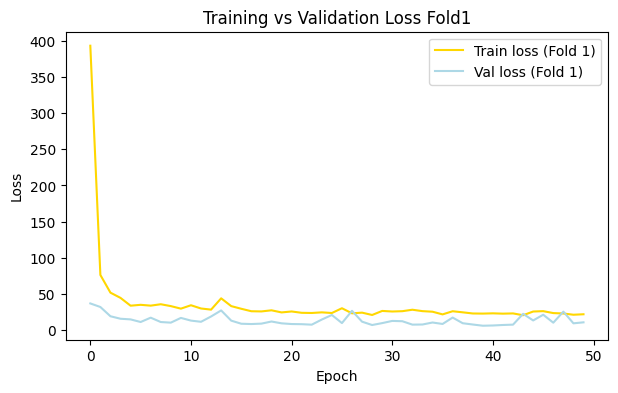

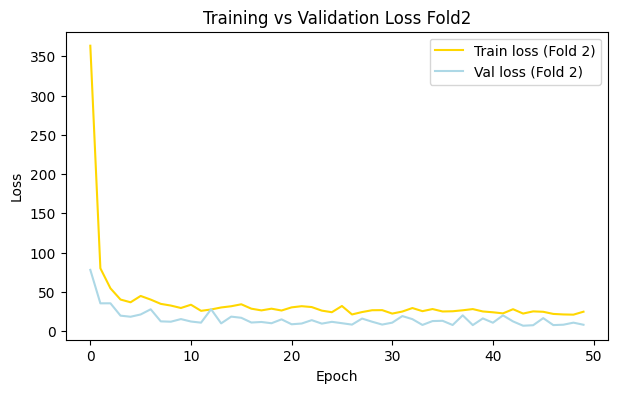

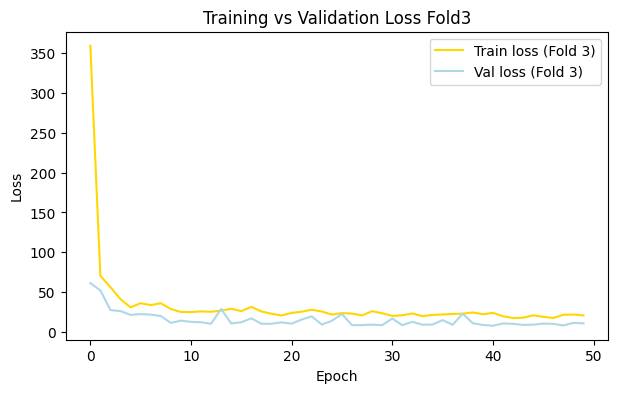

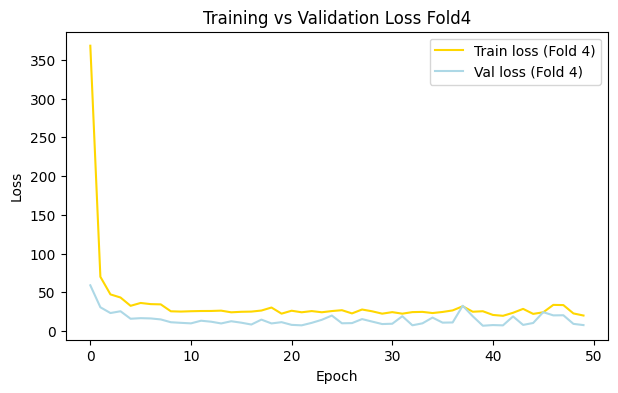

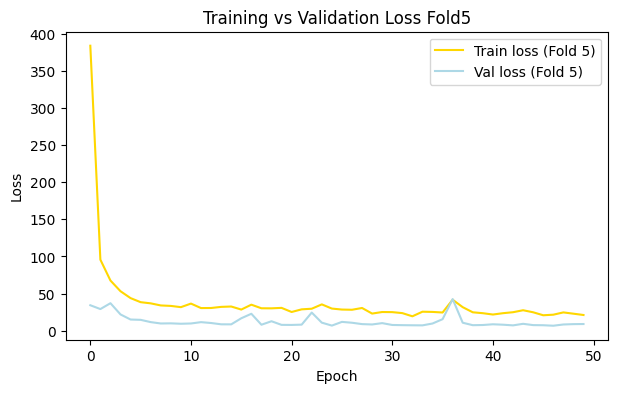

In [20]:
for i in range(len(train_losses_last)):


    plt.figure(figsize=(7,4))
    plt.plot(train_losses_last[i], label=f'Train loss (Fold {i+1})', color='gold')
    plt.plot(val_losses_last[i], label=f'Val loss (Fold {i+1})', color='lightblue')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training vs Validation Loss Fold{i+1}')
    plt.legend()
    plt.show()

With a dropout rate of 10%, the training and validation losses show noticeable fluctuations and are not very smooth.
When the dropout rate was increased ,the results actually worsened, leading to less stable and slightly higher loss values.

#Comparison of Mean Loss Across Cases

In [21]:
comparison_table = pd.DataFrame({
    'Configuration': [
        'Dropout',
        'L2 Regularization',
        '4 Hidden Layers',
        'SGD Optimizer',
        'LR = 0.0001',
        'LR = 0.01'
    ],
    'Mean Loss': [
        mean_loss_dropout,
        mean_loss_regularisation,
        mean_loss_4layers,
        mean_loss_sgd,
        mean_loss_00001,
        mean_loss_001
    ]
})

comparison_table = comparison_table.sort_values(by='Mean Loss', ascending=True)

display(comparison_table)

,Configuration,Mean Loss
2,4 Hidden Layers,8.269152
5,LR = 0.01,8.777783
1,L2 Regularization,9.108563
0,Dropout,9.242296
3,SGD Optimizer,9.925287
4,LR = 0.0001,26.284469
